In [ ]:
from retinaface import RetinaFace
from matplotlib import pyplot as plt
from facenet_pytorch import MTCNN, InceptionResnetV1
import torch
import cv2
from PIL import Image, ImageFilter


In [3]:
import os

os.environ["TF_USE_LEGACY_KERAS"] = "1"

from retinaface import RetinaFace

PATH = "./Assets/img3.jpg"

image = cv2.imread(PATH)

resp = RetinaFace.detect_faces(image)

In [57]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image
from retinaface import RetinaFace
from deepface import DeepFace


class FaceDetector:
    def __init__(
        self,
        model_name="ArcFace",
        distance_metric="cosine",
        detection_threshold=0.7,
        recognition_threshold=0.45
    ):
        self.model_name = model_name
        self.distance_metric = distance_metric
        self.detection_threshold = detection_threshold
        self.recognition_threshold = recognition_threshold

    def _load_image(self, image):
        if isinstance(image, str):
            img = cv2.imread(image)

            if img is None:
                raise ValueError(f"Could not load image: {image}")

            return img

        if isinstance(image, np.ndarray):
            return image.copy()

        if isinstance(image, Image.Image):
            return cv2.cvtColor(
                np.array(image.convert("RGB")),
                cv2.COLOR_RGB2BGR
            )

        raise TypeError(
            "Image must be a path, numpy.ndarray or PIL.Image."
        )

    def _detect_faces(self, target_image):
        image = self._load_image(target_image)

        faces = RetinaFace.detect_faces(
            image,
            threshold=self.detection_threshold,
            allow_upscaling=True
        )

        if not isinstance(faces, dict):
            return {}

        return faces

    def _extract_face_area(self, faces):
        face_areas = []

        for _, values in faces.items():
            if "facial_area" in values:
                face_areas.append(values["facial_area"])

        return face_areas

    def show_faces_area_in_image(self, img):
        image = self._load_image(img)

        faces = self._detect_faces(image)

        if not faces:
            print("No faces detected in the image.")
            return

        face_areas = self._extract_face_area(faces)

        copy_image = image.copy()

        for x1, y1, x2, y2 in face_areas:
            cv2.rectangle(
                copy_image,
                (x1, y1),
                (x2, y2),
                (0, 255, 0),
                2
            )

        cv2.imshow("Faces Detected", copy_image)
        cv2.waitKey(0)
        cv2.destroyAllWindows()

    def _crop_face(self, image, area, padding=0):
        x1, y1, x2, y2 = area

        height, width = image.shape[:2]

        x1 = max(0, x1 - padding)
        y1 = max(0, y1 - padding)
        x2 = min(width, x2 + padding)
        y2 = min(height, y2 + padding)

        face = image[y1:y2, x1:x2]

        if face.size == 0:
            return None

        return face

    def get_face_embeddings(self, target_image):
        image = self._load_image(target_image)

        faces = self._detect_faces(image)

        if not faces:
            print("No faces detected in the image.")
            return None

        face_area = self._extract_face_area(faces)[0]

        face_image = self._crop_face(
            image,
            face_area
        )

        if face_image is None:
            return None

        embeddings = DeepFace.represent(
            img_path=face_image,
            model_name=self.model_name,
            detector_backend="skip",
            enforce_detection=False
        )

        if not embeddings:
            return None

        return np.array(
            embeddings[0]["embedding"]
        )

    def get_face_distance(
        self,
        face_1,
        face_2
    ):
        result = DeepFace.verify(
            img1_path=face_1,
            img2_path=face_2,
            model_name=self.model_name,
            detector_backend="skip",
            distance_metric=self.distance_metric,
            enforce_detection=False
        )

        return result["distance"]

    def get_similarity_between_faces(
        self,
        face_1,
        face_2,
        show_images=False
    ):
        image1 = self._load_image(face_1)
        image2 = self._load_image(face_2)

        faces1 = self._detect_faces(image1)
        faces2 = self._detect_faces(image2)

        if not faces1 or not faces2:
            print("Could not detect one or both faces.")
            return None

        area1 = self._extract_face_area(faces1)[0]
        area2 = self._extract_face_area(faces2)[0]

        crop1 = self._crop_face(image1, area1)
        crop2 = self._crop_face(image2, area2)

        if crop1 is None or crop2 is None:
            return None

        distance = self.get_face_distance(
            crop1,
            crop2
        )

        similarity = 1 - distance

        print(f"Cosine distance: {distance:.4f}")
        print(f"Cosine similarity: {similarity:.4f}")

        if show_images:
            crop1_rgb = cv2.cvtColor(
                crop1,
                cv2.COLOR_BGR2RGB
            )

            crop2_rgb = cv2.cvtColor(
                crop2,
                cv2.COLOR_BGR2RGB
            )

            plt.figure(figsize=(10, 5))

            plt.subplot(1, 2, 1)
            plt.imshow(crop1_rgb)
            plt.title("Face 1")
            plt.axis("off")

            plt.subplot(1, 2, 2)
            plt.imshow(crop2_rgb)
            plt.title("Face 2")
            plt.axis("off")

            plt.tight_layout()
            plt.show()

        return {
            "distance": distance,
            "similarity": similarity
        }

    def is_target_face(
        self,
        target_face,
        candidate_face
    ):
        distance = self.get_face_distance(
            target_face,
            candidate_face
        )

        return distance <= self.recognition_threshold

    def blur_faces_in_image(
        self,
        image,
        target_face,
        blur_strength=51,
        padding=0,
        show_result=False
    ):
        image = self._load_image(image)
        target_image = self._load_image(target_face)

        target_faces = self._detect_faces(target_image)

        if not target_faces:
            raise ValueError("No face detected in target image.")

        target_area = self._extract_face_area(target_faces)[0]

        target_crop = self._crop_face(
            target_image,
            target_area,
            padding=padding
        )

        if target_crop is None:
            raise ValueError("Could not crop target face.")

        output = image.copy()

        faces = self._detect_faces(output)

        if not faces:
            print("No faces detected in the image.")
            return output

        face_areas = self._extract_face_area(faces)

        if blur_strength % 2 == 0:
            blur_strength += 1

        for area in face_areas:
            candidate_face = self._crop_face(
                output,
                area,
                padding=padding
            )

            if candidate_face is None:
                continue

            distance = self.get_face_distance(
                target_crop,
                candidate_face
            )

            print(f"Face distance: {distance:.4f}")

            if distance > self.recognition_threshold:
                x1, y1, x2, y2 = area

                height, width = output.shape[:2]

                x1 = max(0, x1 - padding)
                y1 = max(0, y1 - padding)
                x2 = min(width, x2 + padding)
                y2 = min(height, y2 + padding)

                face_region = output[
                    y1:y2,
                    x1:x2
                ]

                if face_region.size == 0:
                    continue

                blurred_face = cv2.GaussianBlur(
                    face_region,
                    (blur_strength, blur_strength),
                    0
                )

                output[
                    y1:y2,
                    x1:x2
                ] = blurred_face

        if show_result:
            output_rgb = cv2.cvtColor(
                output,
                cv2.COLOR_BGR2RGB
            )

            plt.figure(figsize=(12, 8))
            plt.imshow(output_rgb)
            plt.axis("off")
            plt.show()

        return output

1. _load_image
Shape: (644, 1000, 3)

2. _detect_faces
Faces detectadas: 195
{'face_1': {'score': np.float64(0.9995226860046387), 'facial_area': [np.int64(191), np.int64(175), np.int64(223), np.int64(216)], 'landmarks': {'right_eye': [np.float32(204.92221), np.float32(188.17944)], 'left_eye': [np.float32(219.18123), np.float32(191.87874)], 'nose': [np.float32(212.0482), np.float32(199.27538)], 'mouth_right': [np.float32(201.25473), np.float32(203.71756)], 'mouth_left': [np.float32(213.42345), np.float32(206.83838)]}}, 'face_2': {'score': np.float64(0.9993975162506104), 'facial_area': [np.int64(332), np.int64(251), np.int64(361), np.int64(290)], 'landmarks': {'right_eye': [np.float32(344.1118), np.float32(265.59326)], 'left_eye': [np.float32(357.37396), np.float32(267.37967)], 'nose': [np.float32(351.47534), np.float32(274.05594)], 'mouth_right': [np.float32(342.5639), np.float32(278.35965)], 'mouth_left': [np.float32(354.9428), np.float32(279.87064)]}}, 'face_3': {'score': np.float64(0

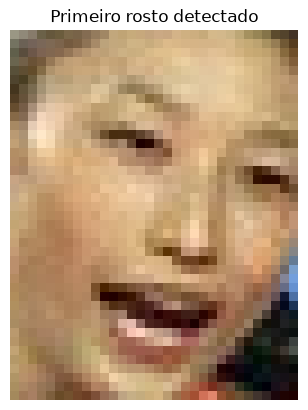


6. get_face_embeddings
Embedding shape: (512,)
Primeiros valores: [-0.03590009  0.1414248   0.17001626 -0.09471372  0.00712223  0.06379612
  0.10033704 -0.04764737  0.10238632  0.02297756]

7. get_similarity_between_faces
Could not detect one or both faces.
Resultado completo:
None

8. blur_faces_in_image
Face distance: 0.8089
Face distance: 0.8366
Face distance: 0.6205
Face distance: 0.9524
Face distance: 0.8368
Face distance: 0.8114
Face distance: 0.8071
Face distance: 0.8347
Face distance: 0.7996
Face distance: 0.7218
Face distance: 0.7990
Face distance: 0.7738
Face distance: 0.9618
Face distance: 0.8371
Face distance: 0.8053
Face distance: 0.8066
Face distance: 0.8925
Face distance: 0.8267
Face distance: 0.7626
Face distance: 0.8150
Face distance: 0.8892
Face distance: 0.7827
Face distance: 0.8355
Face distance: 0.8156
Face distance: 0.8062
Face distance: 0.8119
Face distance: 0.9775
Face distance: 0.8052
Face distance: 0.7964
Face distance: 0.8039
Face distance: 0.1489
Face dista

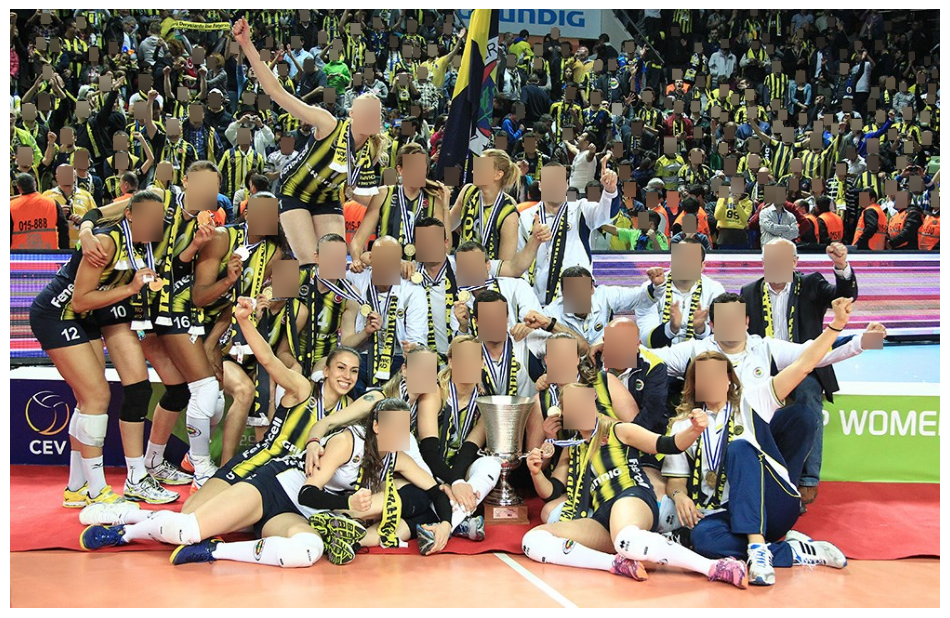


Todos os testes finalizados.


In [58]:
detector = FaceDetector()

IMAGE_PATH = "./Assets/img3.jpg"
TARGET_FACE_PATH = "./Assets/img1.png"
SECOND_FACE_PATH = "./Assets/img2.png"


image = detector._load_image(IMAGE_PATH)

print("1. _load_image")
print("Shape:", image.shape)


print("\n2. _detect_faces")
faces = detector._detect_faces(image)
print("Faces detectadas:", len(faces))
print(faces)


print("\n3. _extract_face_area")
face_areas = detector._extract_face_area(faces)
print("Áreas:")
for area in face_areas:
    print(area)


print("\n4. show_faces_area_in_image")
detector.show_faces_area_in_image(image)


print("\n5. _crop_face")
if face_areas:
    cropped_face = detector._crop_face(
        image,
        face_areas[0]
    )

    print("Shape do rosto:", cropped_face.shape)

    cropped_rgb = cv2.cvtColor(
        cropped_face,
        cv2.COLOR_BGR2RGB
    )

    plt.imshow(cropped_rgb)
    plt.title("Primeiro rosto detectado")
    plt.axis("off")
    plt.show()


print("\n6. get_face_embeddings")
embedding = detector.get_face_embeddings(
    TARGET_FACE_PATH
)

if embedding is not None:
    print("Embedding shape:", embedding.shape)
    print("Primeiros valores:", embedding[:10])


print("\n7. get_similarity_between_faces")
similarity_result = detector.get_similarity_between_faces(
    TARGET_FACE_PATH,
    SECOND_FACE_PATH,
    show_images=True
)

print("Resultado completo:")
print(similarity_result)


print("\n8. blur_faces_in_image")
blurred_image = detector.blur_faces_in_image(
    image=IMAGE_PATH,
    target_face=TARGET_FACE_PATH,
    blur_strength=51,
    show_result=True
)


print("\nTodos os testes finalizados.")

In [47]:
face_1.shape

AttributeError: 'NoneType' object has no attribute 'shape'

In [ ]:
target_image_path = "./Assets/image.png"
target = cv2.imread(target_image_path)
faces_areas = facial_detector._extract_face_area(faces)
facial_detector.blur_faces_in_image(faces_areas,target_image=target, mode="compare", show_result=True)

TypeError: FaceDetector._detect_faces() takes 1 positional argument but 2 were given

Similarity between faces: -0.05521146208047867


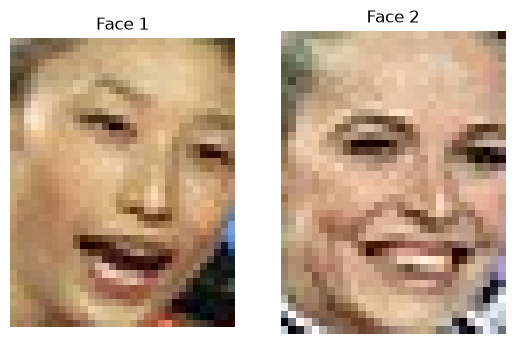

In [44]:

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

facenet = InceptionResnetV1(pretrained='vggface2').eval().to(device)



100%|██████████| 107M/107M [00:04<00:00, 26.4MB/s] 


In [64]:

mtcnn = MTCNN(
    image_size=160,
    margin=1,
    device=device
)
image = faces[0]
opened_image = Image.fromarray(image)
face = mtcnn(opened_image)

face = face.unsqueeze(0).to(device)

with torch.no_grad():
    embedding = facenet(face)

print(embedding.shape)

torch.Size([1, 512])
